In [11]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import mysql.connector
from config import DB_CONFIG

In [2]:
# Load the trained pipeline
final_pipeline = joblib.load("../models/final_churn_model_pipeline.pkl")

In [5]:
# Load the cleaned data (needed to recreate X for feature names / reference)
conn = mysql.connector.connect(**DB_CONFIG)
df = pd.read_sql("select * from ecommerce_cleaned", con = conn)
conn.close()

C:\Users\Ekamjot Singh\AppData\Local\Temp\ipykernel_18164\1077889665.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("select * from ecommerce_cleaned", con = conn)


In [6]:
categorical_cols = ['PreferredLoginDevice', 'CityTier', 'PreferredPaymentMode', 'Gender',
                    'PreferredOrderCat', 'SatisfactionScore','MaritalStatus']
for col in categorical_cols:
    df[col] = df[col].astype('category')

df_model = df.drop(columns=['CustomerID', 'OrderAmountHikeFromlastYear'])

X = df_model.drop(columns=['Churn'])
y = df_model['Churn']

In [7]:
print("Model and data loaded.")
print(final_pipeline)

Model and data loaded.
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('nominal',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['Gender', 'MaritalStatus',
                                                   'PreferredLoginDevice',
                                                   'PreferredPaymentMode',
                                                   'PreferredOrderCat']),
                                                 ('ordinal', 'passthrough',
                                                  ['CityTier',
                                                   'SatisfactionScore']),
                                                 ('numeric', 'passthrough',
                                                  ['Tenure', 'WarehouseToHome',
                                            

In [10]:
# Extract feature importances
# Get the fitted model and preprocessor from the pipeline
model = final_pipeline.named_steps['model']
preprocessor = final_pipeline.named_steps['preprocessor']

# Get the transformed feature names (accounts for one-hot encoded columns)
feature_names = preprocessor.get_feature_names_out()

importances = pd.Series(model.feature_importances_, index=feature_names).sort_values(ascending=False)

print("Top 15 Feature Importances:\n")
print(importances.head(15))

Top 15 Feature Importances:

numeric__Tenure                                  0.212596
binary__Complain                                 0.096278
nominal__PreferredOrderCat_Laptop & Accessory    0.063291
ordinal__SatisfactionScore                       0.047469
ordinal__CityTier                                0.042332
numeric__NumberOfAddress                         0.040703
nominal__PreferredOrderCat_Mobile Phone          0.039068
nominal__MaritalStatus_Single                    0.038279
numeric__DaySinceLastOrder                       0.036486
nominal__PreferredPaymentMode_E wallet           0.033546
nominal__PreferredOrderCat_Others                0.032617
numeric__NumberOfDeviceRegistered                0.031646
nominal__PreferredPaymentMode_UPI                0.031420
nominal__PreferredPaymentMode_Credit Card        0.030022
nominal__PreferredLoginDevice_Mobile Phone       0.028439
dtype: float32


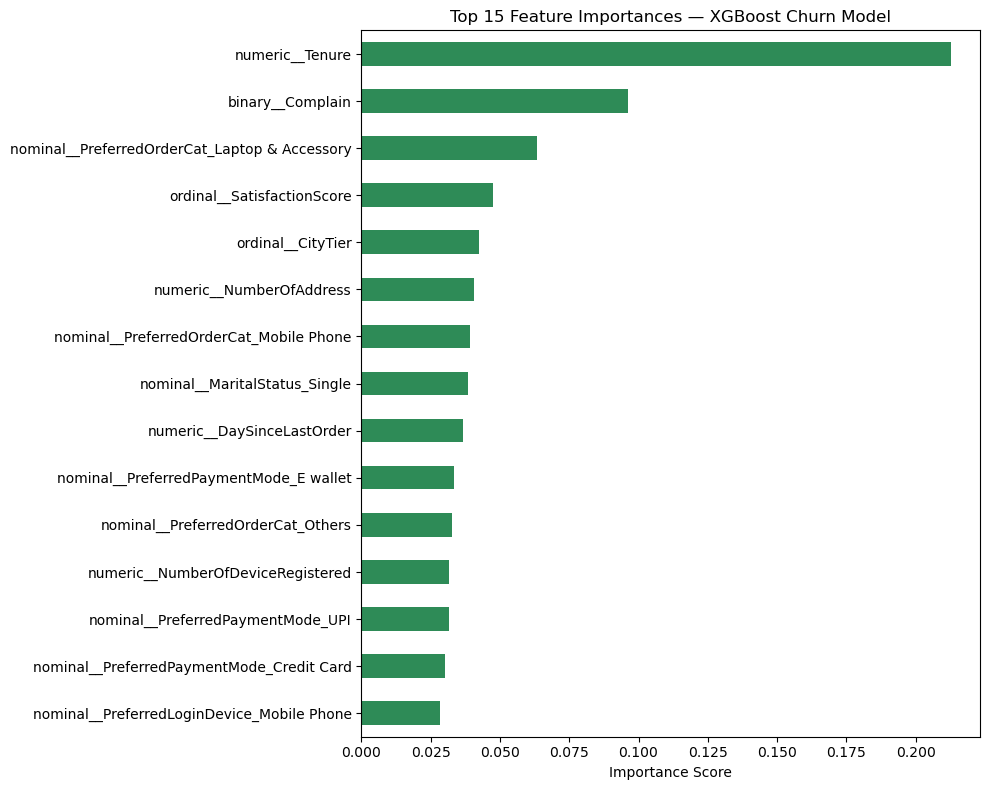

In [14]:
plt.figure(figsize=(10, 8))
top_n = 15
importances.head(top_n).sort_values().plot(kind='barh', color='seagreen')
plt.title(f'Top {top_n} Feature Importances — XGBoost Churn Model')
plt.xlabel('Importance Score')
plt.tight_layout()
# plt.savefig('../eda/feature_importance.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()